# Price vs Distance from Center Correlation Analysis
Analyzing the relationship between hotel prices and their distance from city center.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

## Load Data

In [ ]:
df = pd.read_csv('../data/enriched_hotels_data.csv')
df['search_date'] = pd.to_datetime(df['search_date'], format='%d.%m.%Y')
print(f"Total records: {len(df)}")
df.head()

Total records: 1923


,search_date,day_of_week,location,hotel_id,hotel_name,price,currency,rating,address,city_code,...,is_school_vacation,temp_avg,temp_min,temp_max,precipitation_mm,snow_depth_cm,sunshine_hours,is_ski_season,hotel_chain,is_chain_hotel
0,2026-01-05,Monday,Arosa,BWZRH091,BEST WESTERN HOTEL ZURCHERHOF,570.64,CHF,4.5,"Poststrasse 95, Arosa",ZRH,...,False,-8.2,-11.3,-2.6,4.0,126,4.1,True,Best Western,True
1,2026-01-05,Monday,Arosa,MCZRHDTM,Zurich Marriott Hotel,732.90,CHF,4.5,"Marktplatz 10, Arosa",ZRH,...,False,-5.6,-11.0,-0.9,1.3,64,1.4,True,Marriott,True
2,2026-01-05,Monday,Arosa,ONZRHCTY,HOTEL CITY,438.36,CHF,4.3,"Hauptstrasse 54, Arosa",ZRH,...,False,-6.8,-12.6,-1.4,1.5,142,3.5,True,Independent,False
3,2026-01-05,Monday,Arosa,ONZRHMOT,HOTEL MONTANA,301.46,CHF,4.1,"Poststrasse 9, Arosa",ZRH,...,False,-9.5,-14.4,-5.1,0.0,94,1.3,True,Independent,False
4,2026-01-05,Monday,Arosa,XKZRH001,Hotel du Lac,239.68,CHF,3.9,"Bahnhofstrasse 13, Arosa",ZRH,...,False,-4.9,-9.0,1.9,1.6,131,2.9,True,Independent,False


## Calculate Average Price per Hotel

In [ ]:
hotel_avg = df.groupby('hotel_id').agg({
    'hotel_name': 'first',
    'location': 'first',
    'price': 'mean',
    'distance_from_center': 'first',
    'rating': 'first'
}).reset_index()

hotel_avg.columns = ['hotel_id', 'hotel_name', 'location', 'avg_price', 'distance_from_center', 'rating']
print(f"Total unique hotels: {len(hotel_avg)}")
hotel_avg.head(10)

Total unique hotels: 12


,hotel_id,hotel_name,location,avg_price,distance_from_center,rating
0,BWBRN230,Best Western Plus Hotel Bern,Bern,210.992222,0.12,3.6
1,BWZRH091,BEST WESTERN HOTEL ZURCHERHOF,Arosa,253.021439,107.47,4.5
2,CHGVADHF,DESIGN HOTEL F6,Genf,360.685000,1.22,4.4
3,ICGVAICA,INTERCONTINENTAL GENEVA,Genf,583.731461,2.39,4.3
4,MCZRHDTM,Zurich Marriott Hotel,Arosa,504.625203,108.23,4.5
5,ONBSLBAD,HOTEL BAD BUBENDORF,Basel,174.250000,2.14,3.8
6,ONZRHCTY,HOTEL CITY,Arosa,218.639909,107.95,4.3
7,ONZRHMOT,HOTEL MONTANA,Arosa,202.476667,108.41,4.1
8,RTBSLBAH,ibis Basel Bahnhof,Basel,111.383878,1.46,3.0
9,RTGVAGAR,ibis Geneve Centre Gare,Genf,143.799278,0.52,3.5


## 1. Overall Correlation: Price vs Distance

In [ ]:
# ⚠ NOTE: This overall correlation is not very meaningful due to data quality issues
# (See explanation in Section 2 below)

correlation = hotel_avg['avg_price'].corr(hotel_avg['distance_from_center'])
print(f"\n⚠ Overall Correlation (with caveats): {correlation:.4f}")

if abs(correlation) < 0.3:
    strength = "weak"
elif abs(correlation) < 0.7:
    strength = "moderate"
else:
    strength = "strong"

direction = "negative" if correlation < 0 else "positive"
print(f"Interpretation: {strength} {direction} correlation")

slope, intercept, r_value, p_value, std_err = stats.linregress(hotel_avg['distance_from_center'], hotel_avg['avg_price'])
print(f"\nLinear Regression:")
print(f"  Slope: {slope:.4f}")
print(f"  Intercept: {intercept:.4f}")
print(f"  R-squared: {r_value**2:.4f}")
print(f"  P-value: {p_value:.6f}")

print('\n' + '-'*60)
print('⚠ IMPORTANT: This overall correlation mixes different reference')
print('points. See per-location analysis below for meaningful insights.')
print('-'*60)



⚠ Overall Correlation (with caveats): 0.0492
Interpretation: weak positive correlation

Linear Regression:
  Slope: 0.1382
  Intercept: 244.4393
  R-squared: 0.0024
  P-value: 0.879344

------------------------------------------------------------
⚠ IMPORTANT: This overall correlation mixes different reference
points. See per-location analysis below for meaningful insights.
------------------------------------------------------------


## 2. Scatter Plot with Regression Line

/var/folders/jh/_r4snhk531b72b_klw5898ph0000gn/T/ipykernel_64053/2105162495.py:36: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/mike.spengler/Documents/GitHub/fw_ruemlang/fw_ruemlang/DA_Task/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


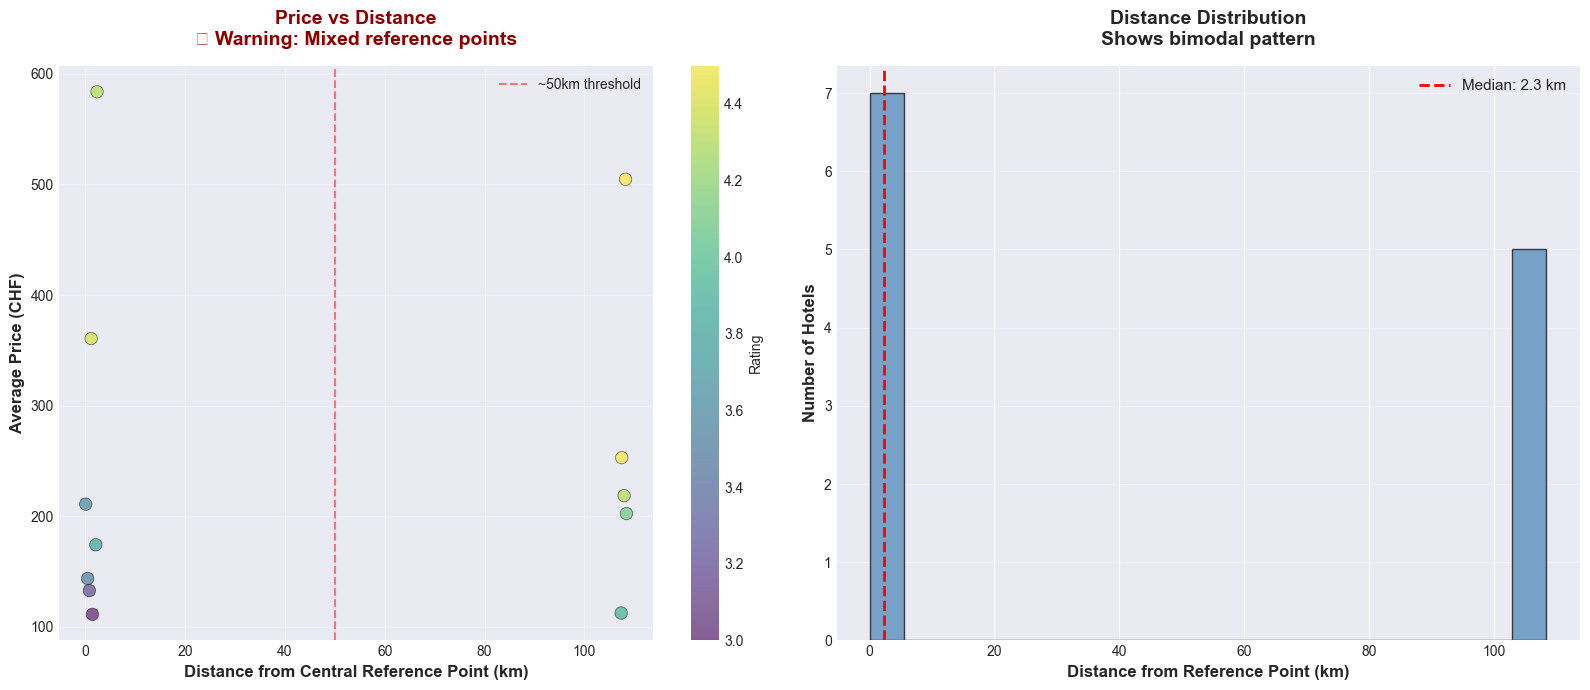


⚠ DATA QUALITY ISSUE: Distance from Center
The "distance_from_center" values measure distance from a CENTRAL
REFERENCE POINT (likely Zurich), NOT from each city's own center.

This means:
  - Geneva hotels: 0.5-2 km (from Geneva center) ✓
  - Arosa hotels: ~107 km (from Zurich, NOT Arosa) ✗
  - Zermatt hotels: ~162 km (from Zurich, NOT Zermatt) ✗

👉 For meaningful analysis, see "Price vs Distance by Location" below


In [ ]:
# NOTE: The 'distance_from_center' column in this dataset is problematic
# It measures distance from a CENTRAL REFERENCE POINT (likely Zurich),
# NOT from each individual city's center.
#
# This creates a bimodal distribution:
# - City hotels (Geneva, Basel, Bern): 0-5 km from their city center ✓
# - Mountain/distant hotels (Arosa, Zermatt): 90-160 km from Zurich ✗
#
# For meaningful analysis, see Section 3 (per-location analysis) instead.

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Show the problematic overall distribution
axes[0].scatter(hotel_avg['distance_from_center'], hotel_avg['avg_price'], 
           alpha=0.6, s=80, c=hotel_avg['rating'], cmap='viridis', 
           edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Distance from Central Reference Point (km)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Price (CHF)', fontsize=12, fontweight='bold')
axes[0].set_title('Price vs Distance\n⚠ Warning: Mixed reference points', 
         fontsize=14, fontweight='bold', pad=15, color='darkred')
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='~50km threshold')
axes[0].colorbar = plt.colorbar(axes[0].collections[0], ax=axes[0], label='Rating')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Show histogram of distances to illustrate the issue
axes[1].hist(hotel_avg['distance_from_center'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(hotel_avg['distance_from_center'].median(), color='red', 
               linestyle='--', linewidth=2, label=f'Median: {hotel_avg["distance_from_center"].median():.1f} km')
axes[1].set_xlabel('Distance from Reference Point (km)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Hotels', fontsize=12, fontweight='bold')
axes[1].set_title('Distance Distribution\nShows bimodal pattern', fontsize=14, fontweight='bold', pad=15)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\n' + '='*70)
print('⚠ DATA QUALITY ISSUE: Distance from Center')
print('='*70)
print('The "distance_from_center" values measure distance from a CENTRAL')
print('REFERENCE POINT (likely Zurich), NOT from each city\'s own center.')
print('\nThis means:')
print('  - Geneva hotels: 0.5-2 km (from Geneva center) ✓')
print('  - Arosa hotels: ~107 km (from Zurich, NOT Arosa) ✗')
print('  - Zermatt hotels: ~162 km (from Zurich, NOT Zermatt) ✗')
print('\n👉 For meaningful analysis, see "Price vs Distance by Location" below')
print('='*70)


## 3. Price vs Distance by Location ⭐ (Meaningful Analysis)


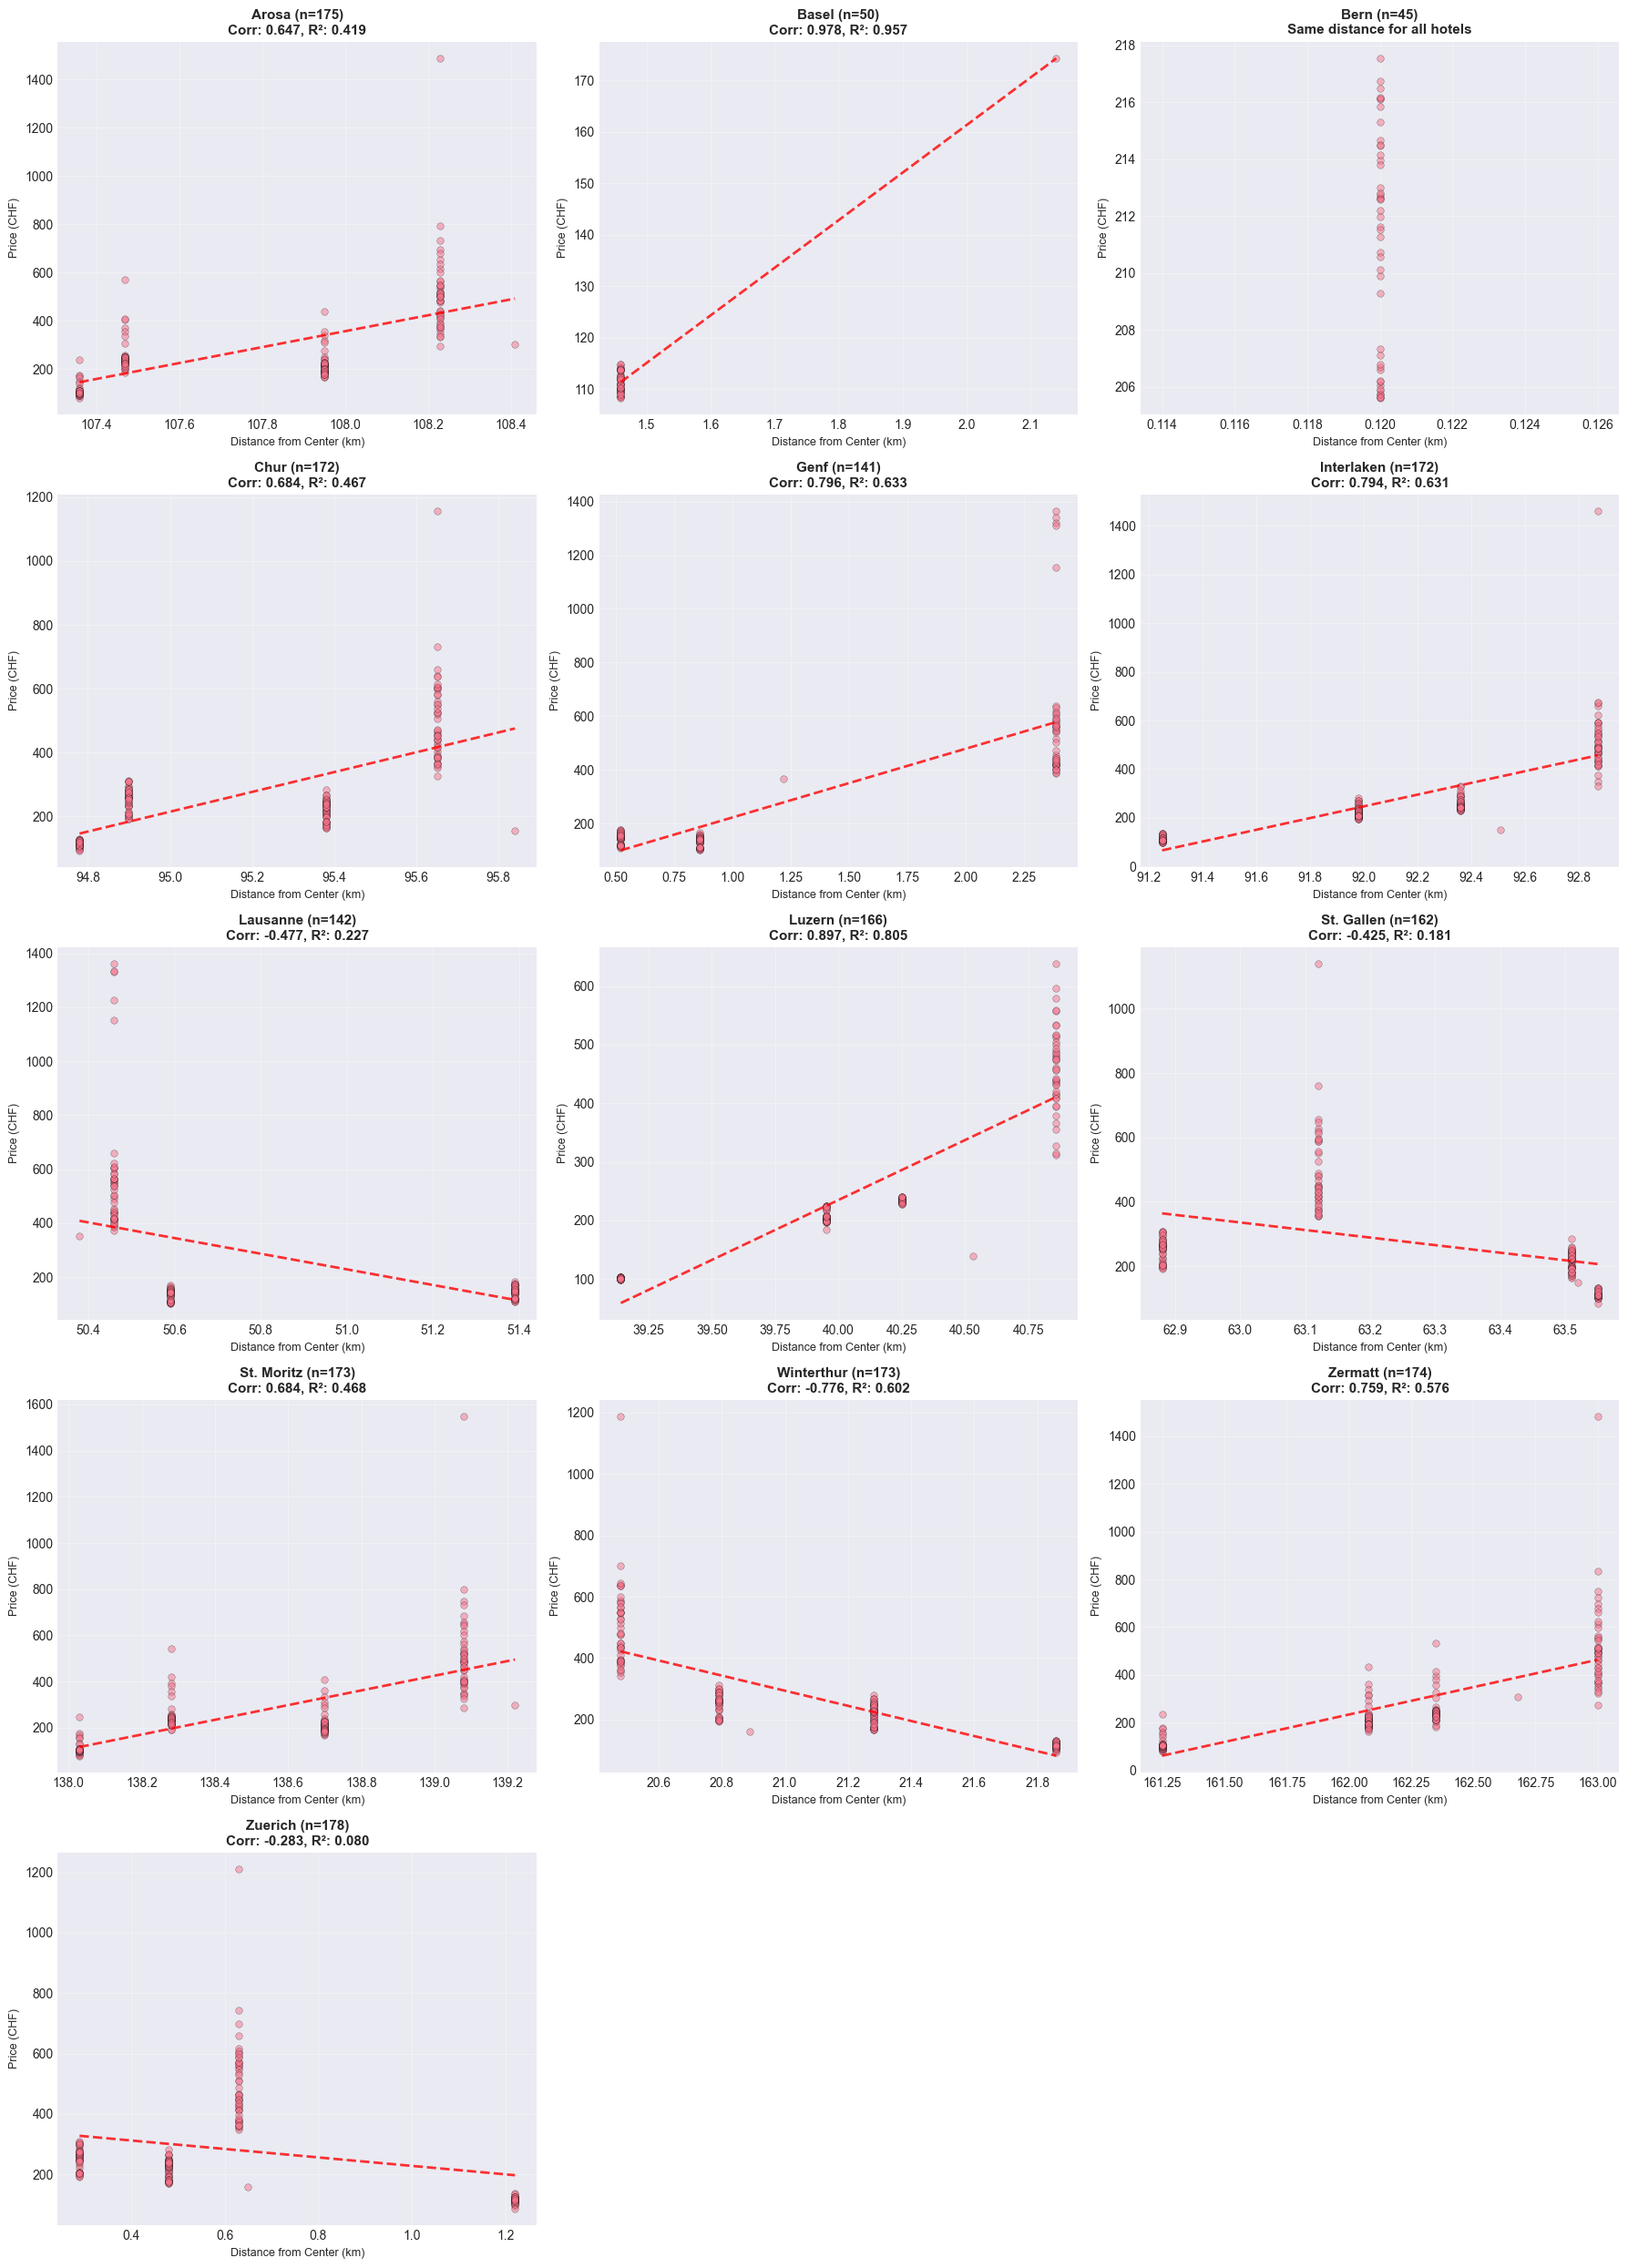

In [ ]:
# Use full dataset grouped by location for comprehensive analysis
locations = df['location'].unique()
n_locations = len(locations)
n_cols = 3
n_rows = (n_locations + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for idx, location in enumerate(sorted(locations)):
    location_data = df[df['location'] == location]
    ax = axes[idx]
    
    ax.scatter(location_data['distance_from_center'], location_data['price'], 
              alpha=0.5, s=30, edgecolors='black', linewidth=0.3)
    
    # Check if we have variance in distance values
    unique_distances = location_data['distance_from_center'].nunique()
    
    if len(location_data) > 1 and unique_distances > 1:
        loc_corr = location_data['price'].corr(location_data['distance_from_center'])
        loc_slope, loc_intercept, loc_r, _, _ = stats.linregress(
            location_data['distance_from_center'], location_data['price'])
        
        x_line = np.linspace(location_data['distance_from_center'].min(), 
                           location_data['distance_from_center'].max(), 100)
        y_line = loc_slope * x_line + loc_intercept
        ax.plot(x_line, y_line, 'r--', linewidth=2, alpha=0.8)
        
        ax.set_title(f'{location} (n={len(location_data)})\nCorr: {loc_corr:.3f}, R²: {loc_r**2:.3f}', 
                    fontweight='bold', fontsize=11)
    elif unique_distances == 1:
        ax.set_title(f'{location} (n={len(location_data)})\nSame distance for all hotels', 
                    fontweight='bold', fontsize=11)
    else:
        ax.set_title(f'{location}\n(Insufficient data)', fontweight='bold', fontsize=11)
    
    ax.set_xlabel('Distance from Center (km)', fontsize=9)
    ax.set_ylabel('Price (CHF)', fontsize=9)
    ax.grid(True, alpha=0.3)

for idx in range(n_locations, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

## 4. Correlation Analysis by Location

In [ ]:
location_correlations = []

for location in sorted(df['location'].unique()):
    location_data = df[df['location'] == location]
    # Only calculate correlation if we have variance in distance
    if len(location_data) > 1 and location_data['distance_from_center'].nunique() > 1:
        corr = location_data['price'].corr(location_data['distance_from_center'])
        location_correlations.append({
            'Location': location,
            'Correlation': corr,
            'Record_Count': len(location_data),
            'Avg_Price': location_data['price'].mean(),
            'Avg_Distance': location_data['distance_from_center'].mean()
        })

corr_df = pd.DataFrame(location_correlations).sort_values('Correlation', ascending=False)
corr_df['Correlation'] = corr_df['Correlation'].round(4)
corr_df['Avg_Price'] = corr_df['Avg_Price'].round(2)
corr_df['Avg_Distance'] = corr_df['Avg_Distance'].round(2)

print("\nCorrelation by Location (locations with varying distances):")
print(corr_df.to_string(index=False))
print(f"\nNote: {13 - len(corr_df)} location(s) excluded (all hotels same distance from center)")


Correlation by Location (locations with varying distances):
  Location  Correlation  Record_Count  Avg_Price  Avg_Distance
     Basel       0.9782            50     112.64          1.47
    Luzern       0.8974           166     257.88         40.11
      Genf       0.7957           141     279.80          1.22
Interlaken       0.7943           172     288.06         92.17
   Zermatt       0.7591           174     284.33        162.22
St. Moritz       0.6840           173     285.02        138.56
      Chur       0.6836           172     280.40         95.21
     Arosa       0.6473           175     284.66        107.78
   Zuerich      -0.2834           178     281.20          0.62
St. Gallen      -0.4253           162     277.30         63.25
  Lausanne      -0.4768           142     280.23         50.82
Winterthur      -0.7758           173     278.69         21.06

Note: 1 location(s) excluded (all hotels same distance from center)


## 5. Visualize Correlation Coefficients by Location

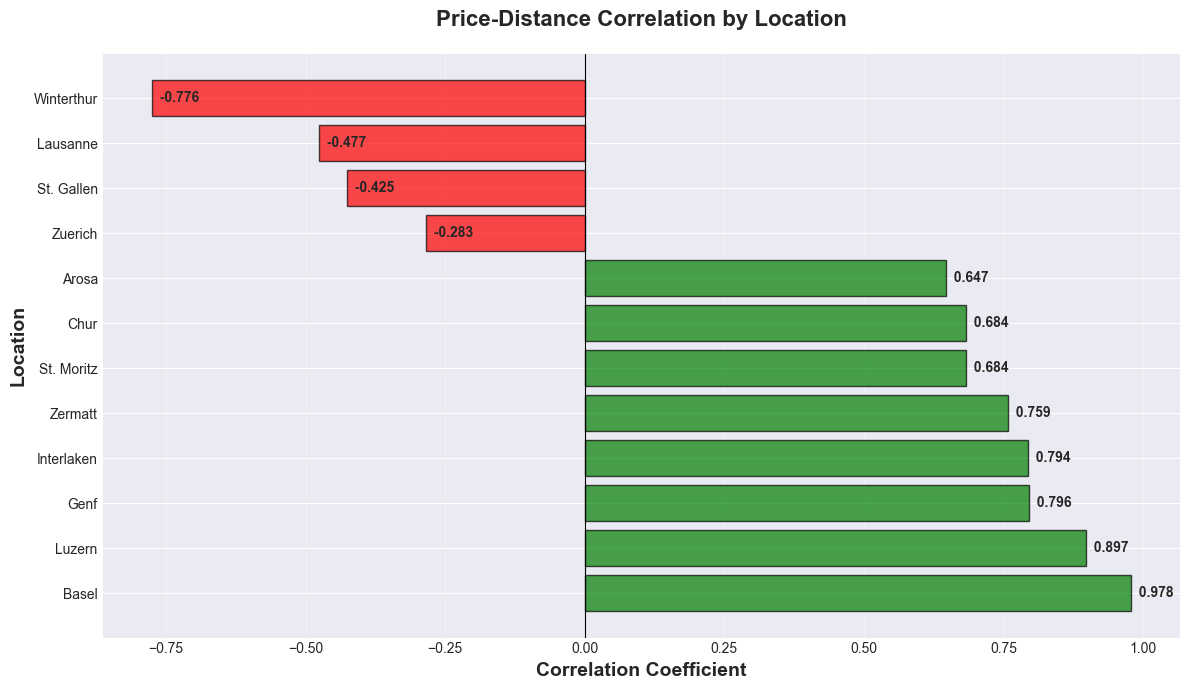

In [ ]:
plt.figure(figsize=(12, 7))
colors = ['green' if c > 0 else 'red' for c in corr_df['Correlation']]
bars = plt.barh(corr_df['Location'], corr_df['Correlation'], color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Correlation Coefficient', fontsize=14, fontweight='bold')
plt.ylabel('Location', fontsize=14, fontweight='bold')
plt.title('Price-Distance Correlation by Location', fontsize=16, fontweight='bold', pad=20)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')

for i, (location, corr) in enumerate(zip(corr_df['Location'], corr_df['Correlation'])):
    plt.text(corr, i, f'  {corr:.3f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Distance Categories Analysis


Price Statistics by Distance Category:
                    Mean_Price  Median_Price  Hotel_Count
distance_category                                        
Very Close (0-2km)      191.95        143.80            5
Close (2-5km)           378.99        378.99            2
Very Far (50+km)        258.27        218.64            5


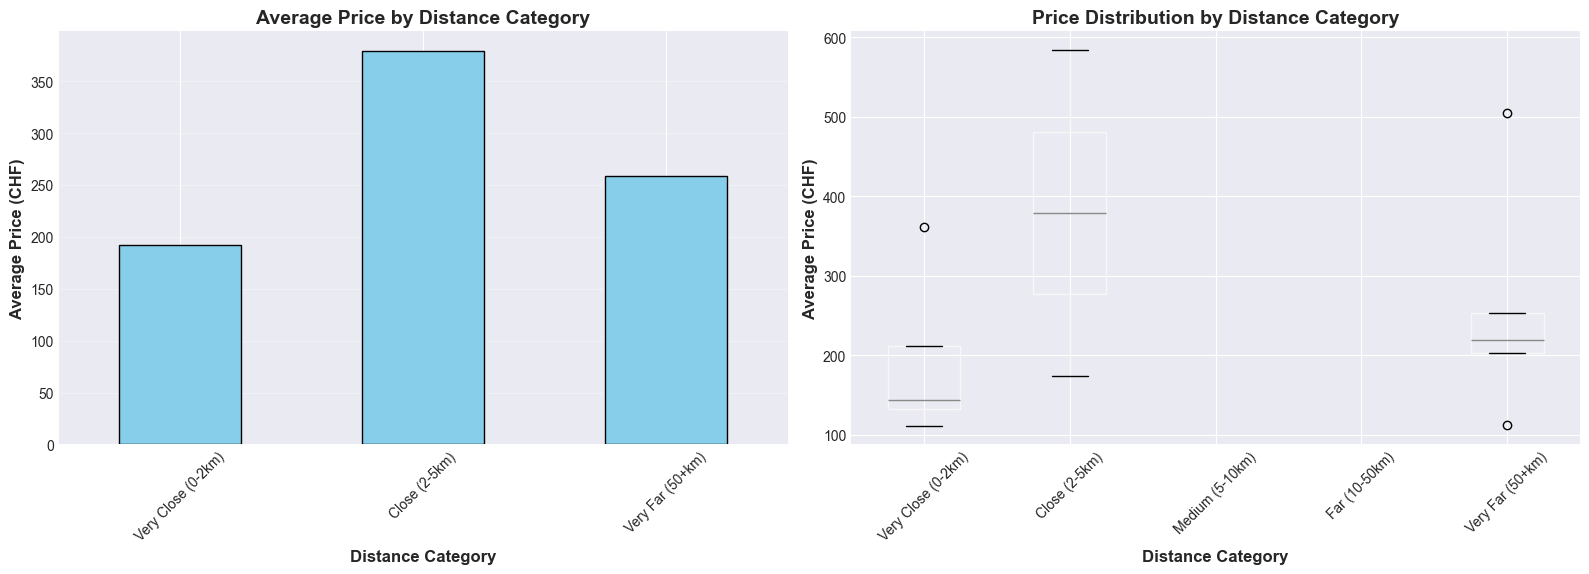

In [ ]:
hotel_avg['distance_category'] = pd.cut(hotel_avg['distance_from_center'], 
                                        bins=[0, 2, 5, 10, 50, 200],
                                        labels=['Very Close (0-2km)', 'Close (2-5km)', 
                                               'Medium (5-10km)', 'Far (10-50km)', 'Very Far (50+km)'])

category_stats = hotel_avg.groupby('distance_category', observed=True).agg({
    'avg_price': ['mean', 'median', 'count']
}).round(2)

category_stats.columns = ['Mean_Price', 'Median_Price', 'Hotel_Count']
print("\nPrice Statistics by Distance Category:")
print(category_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

category_stats['Mean_Price'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Distance Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Price (CHF)', fontsize=12, fontweight='bold')
axes[0].set_title('Average Price by Distance Category', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

hotel_avg.boxplot(column='avg_price', by='distance_category', ax=axes[1])
axes[1].set_xlabel('Distance Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Price (CHF)', fontsize=12, fontweight='bold')
axes[1].set_title('Price Distribution by Distance Category', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle('')

plt.tight_layout()
plt.show()

## Summary Insights

In [ ]:
print("\n" + "="*60)
print("CORRELATION ANALYSIS SUMMARY")
print("="*60)
print(f"\nOverall Correlation: {correlation:.4f}")
print(f"Interpretation: {strength.capitalize()} {direction} relationship")
print(f"\nStatistical Significance: {'Yes' if p_value < 0.05 else 'No'} (p-value: {p_value:.6f})")
print(f"\nKey Findings:")
print(f"  - Average hotel price: {hotel_avg['avg_price'].mean():.2f} CHF")
print(f"  - Average distance from center: {hotel_avg['distance_from_center'].mean():.2f} km")
print(f"  - Price range: {hotel_avg['avg_price'].min():.2f} - {hotel_avg['avg_price'].max():.2f} CHF")
print(f"  - Distance range: {hotel_avg['distance_from_center'].min():.2f} - {hotel_avg['distance_from_center'].max():.2f} km")
print("\n" + "="*60)


CORRELATION ANALYSIS SUMMARY

Overall Correlation: 0.0492
Interpretation: Weak positive relationship

Statistical Significance: No (p-value: 0.879344)

Key Findings:
  - Average hotel price: 250.75 CHF
  - Average distance from center: 45.68 km
  - Price range: 111.38 - 583.73 CHF
  - Distance range: 0.12 - 108.41 km

